1️⃣ Problem Statement

Extract hidden topics from 6000 unlabeled documents using NMF and analyze document-topic distribution.



2️⃣ Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import normalize


3️⃣ Load Dataset

In [ ]:
df = pd.read_csv("/content/nmf_documents_dataset.csv")

In [ ]:
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (6000, 2)


,doc_id,text
0,1,basketball olympics training football cricket ...
1,2,academic growth student performance curriculum...
2,3,university scholarship curriculum research stu...
3,4,e-learning academic growth classroom online le...
4,5,cricket football training championship olympic...


4️⃣ Text Preprocessing + TF-IDF

NMF works best with TF-IDF features.

In [ ]:
tfidf = TfidfVectorizer(
    max_df=0.95,
    min_df=2,
    stop_words='english'
)

dtm = tfidf.fit_transform(df['text'])

print("DTM Shape:", dtm.shape)


DTM Shape: (6000, 66)


Rows = Documents

Columns = Unique Words

5️⃣ Build NMF Model

In [ ]:
n_topics = 5

nmf_model = NMF(
    n_components=n_topics,
    random_state=42,
    init='nndsvda'
)

W = nmf_model.fit_transform(dtm)   # Document-Topic Matrix
H = nmf_model.components_          # Topic-Word Matrix


6️⃣ Extract Top Words Per Topic

In [ ]:
# display topic
feature_names = tfidf.get_feature_names_out()
for topic_idx, topic in enumerate(H):
    print(f"\nTopic {topic_idx+1}:")
    top_words = [feature_names[i] for i in topic.argsort()[-11:]]
    print(top_words)


Topic 1:
['software', 'blockchain', 'machine', 'big', 'science', 'intelligence', 'artificial', 'cloud', 'computing', 'technology', 'data']

Topic 2:
['nutrition', 'medical', 'diabetes', 'exercise', 'immunity', 'healthy', 'diet', 'vaccination', 'public', 'mental', 'health']

Topic 3:
['economic', 'inflation', 'funds', 'mutual', 'cryptocurrency', 'revenue', 'market', 'stock', 'financial', 'planning', 'finance']

Topic 4:
['examination', 'scholarship', 'classroom', 'curriculum', 'performance', 'student', 'academic', 'university', 'online', 'learning', 'education']

Topic 5:
['training', 'coach', 'football', 'tournament', 'championship', 'athlete', 'cricket', 'tennis', 'olympics', 'basketball', 'sports']


7️⃣ Assign Dominant Topic to Each Document

In [ ]:
df['Dominant_Topic'] = np.argmax(W, axis=1)
df.head()


,doc_id,text,Dominant_Topic
0,1,basketball olympics training football cricket ...,4
1,2,academic growth student performance curriculum...,7
2,3,university scholarship curriculum research stu...,6
3,4,e-learning academic growth classroom online le...,1
4,5,cricket football training championship olympic...,8


8️⃣ Topic Distribution Analysis

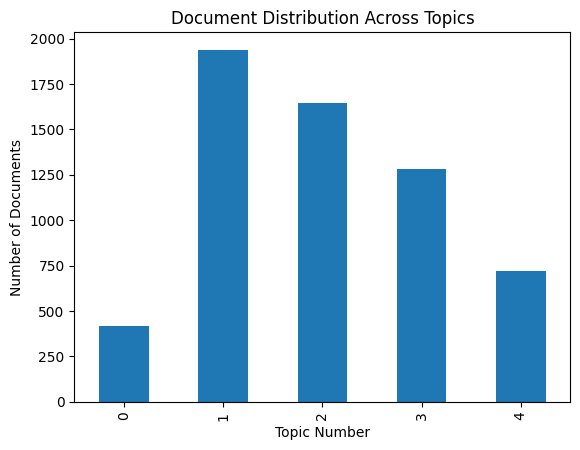

In [ ]:
topic_counts = df['Dominant_Topic'].value_counts().sort_index()

plt.figure()
topic_counts.plot(kind='bar')
plt.xlabel("Topic Number")
plt.ylabel("Number of Documents")
plt.title("Document Distribution Across Topics")
plt.show()


9️⃣ Normalize Topic Probabilities (Optional Advanced Step)
Now each row sums to 1 (probability distribution).

In [ ]:
W_normalized = normalize(W, norm='l1')


🔟 Save Final Output

In [ ]:
df.to_csv("nmf_output_with_topics.csv", index=False)


📊 Evaluation

In [ ]:
print("Reconstruction Error:", nmf_model.reconstruction_err_)


Reconstruction Error: 50.737704275739276


🔬 How to Check If Model Is Improving?

Try changing number of topics:

In [ ]:
for k in [3, 5, 7, 10]:
    nmf = NMF(n_components=k, random_state=42)
    W = nmf.fit_transform(dtm)
    print(f"Topics: {k}, Error: {nmf.reconstruction_err_}")


Topics: 3, Error: 59.007244063765334
Topics: 5, Error: 50.737704275739276
Topics: 7, Error: 48.94617941105614
Topics: 10, Error: 46.02573461487341
